### 引言
为了突破线性的限制，我们需要引入“非线性”这个强大的武器。这就是多层感知机（MLP）的核心思想：**通过堆叠多个线性层，并在它们之间加入非线性激活函数，从而能够拟合任意复杂的函数**。

*   **核心思想**：
    1.  **增加“隐藏层”**：在输入层和输出层之间，加入一个或多个中间层。
    2.  **引入“激活函数”**：在每个隐藏层的输出上，应用一个非线性函数（如 ReLU, Sigmoid），这是MLP拥有强大能力的源泉。

*   **结构对比**：
    *   **线性/Softmax回归**：`输入 → 线性变换 → 输出`
    *   **MLP**：`输入 → 线性变换 → **激活函数** → 线性变换 → **激活函数** → ... → 输出`

*   **关键组件**：
    *   **隐藏层 (Hidden Layer)**：负责将原始输入特征变换到一个新的、更高维度的空间。在这个新空间里，原本线性不可分的问题可能就变得可以分开了。
    *   **激活函数 (Activation Function)**：
        *   **ReLU**：`f(x) = max(0, x)`。它像一扇门，只让正数通过。正是这种简单的非线性，赋予了网络拟合复杂模式的能力。
        *   **Sigmoid/Tanh**：将输出压缩到特定范围（如0-1或-1到1），常用于二分类的输出层。

*   **能做什么**：几乎所有复杂的机器学习任务，如图像识别、自然语言处理、游戏AI等。理论上，只要有足够多的隐藏层和神经元，MLP可以以任意精度逼近任何连续函数（这被称为**通用近似定理**）。


| 模型 | 核心结构 | 能力 | 局限性 |
| :--- | :--- | :--- | :--- |
| **线性回归** | `y = wX + b` | 拟合线性关系，预测连续值 | 无法处理非线性问题 |
| **Softmax回归** | `P(y) = Softmax(wX + b)` | 解决多分类问题，输出概率 | 决策边界仍是线性的 |
| **MLP** | `... → Linear → ReLU → Linear → ...` | 拟合任意复杂的非线性关系 | 需要更多数据、调参，易过拟合 |

### 隐藏层和激活函数
![MLP.png](./PPT-figure/MLP.png)

如图所示，多层感知机就是有不止一层计算单元的神经网络。然而，不管堆叠多少层都无法拟合出非线性的曲线，因此，在每一层线性变换之后引入非线性的“激活函数”，为模型引入复杂的非线性关系。通过“线性变换 → 非线性激活 → 线性变换 → ...”这样的交替堆叠，多层感知机能够学习和逼近任意复杂的函数关系。
$$
h = \sigma(xw+b)
$$

借助于激活函数，多层感知机通过多层隐藏层和非线性激活函数的组合，可以构建出极其复杂的、弯曲的决策边界，从而解决像异或（XOR）问题这样线性模型无法处理的复杂任务。

多层感知机可以通过隐藏神经元，捕捉到输入之间复杂的相互作用， 这些神经元依赖于每个输入的值。 我们可以很容易地设计隐藏节点来执行任意计算。 例如，在一对输入上进行基本逻辑操作，多层感知机是通用近似器。 即使是网络只有一个隐藏层，给定足够的神经元和正确的权重， 我们可以对任意函数建模，尽管实际中学习该函数是很困难的。 神经网络有点像C语言。 C语言和任何其他现代编程语言一样，能够表达任何可计算的程序。 但实际上，想出一个符合规范的程序才是最困难的部分。

而且，虽然一个单隐层网络能学习任何函数， 但并不意味着我们应该尝试使用单隐藏层网络来解决所有问题。 事实上，通过使用更深（而不是更广）的网络，我们可以更容易地逼近许多函数。 我们将在后面的章节中进行更细致的讨论。

### 激活函数分类

激活函数（Activation Function）是神经网络中的“灵魂”组件。如果把神经元之间的连接（权重）比作大脑的突触连接，那么激活函数就是决定神经元是否“兴奋”或“抑制”的机制。
没有激活函数，无论你的神经网络有多少层，它最终都只是一个简单的线性回归模型，无法解决复杂的非线性问题（比如识别猫和狗，或者理解人类语言）。
为了让你更直观地理解，我们可以把激活函数比作一个“决策关卡”：它接收上一层传来的信号，决定这个信号是继续传递下去，还是被过滤掉，或者是被缩小、放大。

#### 1. sigmoid
对于一个定义域在$\mathbb{R}$中的输入， sigmoid函数将输入变换为区间(0, 1)上的输出。 因此，sigmoid通常称为挤压函数（squashing function）： 它将范围（-inf, inf）中的任意输入压缩到区间（0, 1）中的某个值：
$$
sigmoid(x) = \frac{1}{1+exp(-x)}
$$

当人们逐渐关注到到基于梯度的学习时， sigmoid函数是一个自然的选择，因为它是一个**平滑的、可微**的函数。 当我们想要将输出视作**分类**问题的概率时， sigmoid仍然被广泛用作输出单元上的激活函数，因为输出范围在0到1之间。 然而，sigmoid在隐藏层中已经**较少使用**， 它在大部分时候被更简单、更容易训练的ReLU所取代，因为它的缺点：
- 梯度消失：当输入值非常大或非常小时，函数的导数趋近于 0，导致深层网络无法训练（梯度传不回去）。
- 计算量大：包含指数运算，计算成本高。
- 输出非零中心化：输出都是正数，会导致后续层的梯度更新（要么一起变大，要么一起变小）方向呈现“锯齿状”，降低收敛效率。

#### 2. tanh
与sigmoid函数类似， tanh(双曲正切)函数也能将其输入压缩转换到区间(-1, 1)上。 tanh函数的公式如下：
$$
tanh(x) = \frac{1 - exp(-2x)}{1 + exp(-2x)}
$$

注意，当输入在0附近时，tanh函数接近线性变换。 函数的形状类似于sigmoid函数， 不同的是tanh函数关于坐标系原点中心对称。

- 优点：零中心化：输出均值为 0，解决了 Sigmoid 导致的梯度更新效率低的问题，收敛速度通常比 Sigmoid 快。
- 缺点：依然存在梯度消失问题，不适合极深的网络。

#### 3. ReLU (线性整流单元)
最受欢迎的激活函数是修正线性单元（Rectified linear unit，ReLU）， 因为它实现简单，同时在各种预测任务中表现良好。 ReLU提供了一种非常简单的非线性变换。 给定元素x，ReLU函数被定义为该元素与0的最大值：
$$
RELU(x) = max(x,0).
$$

当输入为负时，ReLU函数的导数为0，而当输入为正时，ReLU函数的导数为1。 注意，当输入值精确等于0时，ReLU函数不可导。 在此时，我们默认使用左侧的导数，即当输入为0时导数为0。 我们可以忽略这种情况，因为输入可能永远都不会是0。使用ReLU的原因是，它求导表现得特别好：**要么让参数消失，要么让参数通过**。 这使得优化表现得更好，并且ReLU减轻了困扰以往神经网络的梯度消失问题。
优点：
- 计算极快：只需要一个阈值判断，没有复杂的指数运算。
- 缓解梯度消失：在正区间梯度恒为 1，使得深层网络的训练成为可能。
- 稀疏激活：一部分神经元输出为 0，这使得网络更加稀疏，提高了计算效率和抗过拟合能力。
缺点：
- 神经元死亡（Dead ReLU）：如果某个神经元在训练初始化时输入一直为负，它的梯度就会变成 0 且不再更新，导致该神经元永久“死亡”，不再对任何数据有反应。

#### 总结

| 激活函数 | 核心特点 | 优点 | 缺点 | 推荐使用场景 |
| :--- | :--- | :--- | :--- | :--- |
| ReLU | `max(0, x)` | 计算极快，缓解梯度消失 | 神经元易死亡 | CNN/MLP 隐藏层默认首选 |
| Sigmoid | 输出 (0, 1) | 适合概率解释 | 梯度消失，计算慢 | 二分类输出层 |
| Tanh | 输出 (-1, 1) | 零中心化，优于 Sigmoid | 仍有梯度消失 | 早期 RNN，现较少用 |

### 多层感知机实现

依然使用第二章softmax回归训练的mnist训练集进行训练，对手写数字进行分类。

In [9]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# 1. 数据准备
# 将图片从 28x28 展平成 784 的向量，并进行归一化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 下载并加载 MNIST 数据集
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [3]:
# 2. 定义模型
# 对比：如果是 Softmax 回归，这里只需要 nn.Linear(784, 10)
# MLP 结构：输入(784) -> 隐藏层(256) -> 激活(ReLU) -> 输出(10)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(784, 256),  # 第一层：784个输入 -> 256个隐藏单元
            nn.ReLU(),            # 关键：引入非线性
            nn.Linear(256, 10)    # 第二层：256个隐藏单元 -> 10个类别
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

model = MLP()

In [4]:
# 3. 定义损失函数和优化器
# 交叉熵损失函数（内部包含了 Softmax）
loss_fn = nn.CrossEntropyLoss()
# 随机梯度下降
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [5]:
# 4. 训练函数
def train(model, loader, loss_fn, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for X, y in loader:
        pred = model(X)
        loss = loss_fn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [6]:
# 5. 测试函数
def test(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in loader:
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    return correct / len(loader.dataset)

In [7]:
# 6. 开始训练循环
print(f"{'Epoch':<5} | {'Train Loss':<10} | {'Train Acc':<10} | {'Test Acc':<10}")
print("-" * 45)
num_epochs = 5
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, loss_fn, optimizer)
    test_acc = test(model, test_loader)
    print(f"{epoch+1:<5} | {train_loss:<10.4f} | {train_acc:<10.4f} | {test_acc:<10.4f}")

Epoch | Train Loss | Train Acc  | Test Acc  
---------------------------------------------
1     | 0.4115     | 0.8866     | 0.9279    
2     | 0.2098     | 0.9397     | 0.9501    
3     | 0.1578     | 0.9548     | 0.9572    
4     | 0.1279     | 0.9636     | 0.9643    
5     | 0.1076     | 0.9701     | 0.9675    


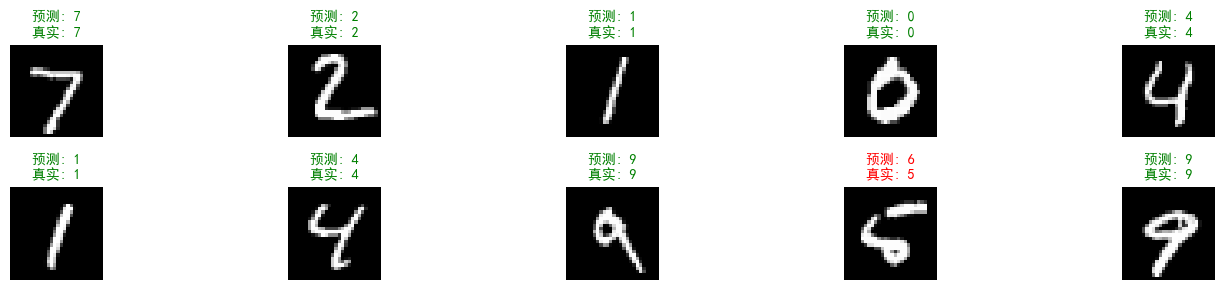

In [10]:
# ==========================================
# 7. 可视化预测结果
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei']
# 随便拿一批测试数据看看
iterator = iter(test_loader) # 迭代器
images, labels = next(iterator)
outputs = model(images)
_, predicted = torch.max(outputs.data, 1)

plt.figure(figsize=(15, 3))
for i in range(10): # 显示前10张图
    plt.subplot(2, 5, i+1)
    # 反归一化用于显示 (img * std + mean)
    img = images[i] * 0.3081 + 0.1307 
    plt.imshow(img.squeeze().numpy(), cmap='gray')
    
    # 预测对了显示绿色，错了显示红色
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f"预测: {predicted[i].item()}\n真实: {labels[i].item()}", color=color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

可以看到，准确率96.75% > 91.33%。